<a href="https://colab.research.google.com/github/mikaeladepaula/telecom-x-churn-analysis/blob/main/TelecomX_Analise_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests

# Link direto para os dados brutos (Raw) da Telecom X
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

# Ler os dados JSON e transformar em um DataFrame (Tabela)
df_telecom = pd.read_json(url)

# Mostrar as primeiras 5 linhas para ver se funcionou
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
# Verificar o tamanho da tabela (Linhas, Colunas)
print(f"A base possui {df_telecom.shape[0]} clientes e {df_telecom.shape[1]} colunas.\n")

# Verificar os tipos de dados e valores nulos
df_telecom.info()

A base possui 7267 clientes e 6 colunas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [3]:
# 1. Transformação (Normalização)
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# Juntar tudo no DataFrame principal
df_clean = pd.concat([df_telecom[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 2. Verificação de Tipos de Dados (Exploração)
print("--- RESUMO DE COLUNAS E TIPOS ---")
df_clean.info()

--- RESUMO DE COLUNAS E TIPOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract

In [4]:
# 1. Verificar se existem linhas duplicadas
duplicados = df_clean.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicados}")

# 2. Investigar por que Charges.Total é texto (procurando espaços vazios)
vazios_total = df_clean[df_clean['Charges.Total'] == ' '].shape[0]
print(f"Clientes com 'Charges.Total' em branco: {vazios_total}")

# 3. Verificar os valores únicos da coluna Churn (nossa variável alvo)
print(f"Valores únicos na coluna Churn: {df_clean['Churn'].unique()}")

Linhas duplicadas encontradas: 0
Clientes com 'Charges.Total' em branco: 11
Valores únicos na coluna Churn: ['No' 'Yes' '']


In [5]:
# 1. Remover os clientes com Churn vazio (os '')
# Isso garante que a análise seja baseada apenas em fatos confirmados
df_clean = df_clean[df_clean['Churn'] != ''].copy()

# 2. Transformar Charges.Total em número e tratar os 11 espaços vazios
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce').fillna(0)

# 3. Verificar se as correções funcionaram
print(f"Total de clientes após a limpeza: {len(df_clean)}")
print(f"Valores únicos no Churn agora: {df_clean['Churn'].unique()}")

Total de clientes após a limpeza: 7043
Valores únicos no Churn agora: ['No' 'Yes']


In [6]:
# Criar coluna arredondada para 2 casas decimais
df_clean['Contas_Diarias'] = (df_clean['Charges.Monthly'] / 30).round(2)

# Visualizar se a conta deu certo
print("Métrica de Contas Diárias criada!")
df_clean[['customerID', 'Charges.Monthly', 'Contas_Diarias']].head()

Métrica de Contas Diárias criada!


,customerID,Charges.Monthly,Contas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [7]:
# 1. Dicionário de tradução das colunas
traducao = {
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Faturamento_Mensal',
    'Charges.Total': 'Faturamento_Total'
}

# Renomear as colunas
df_clean = df_clean.rename(columns=traducao)

# 2. Criar o Churn Binário (1 para quem saiu, 0 para quem ficou)
df_clean['Churn_Binario'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Conferir o resultado final da tabela tratada
print("Tradução e padronização concluídas!")
df_clean.head()

Tradução e padronização concluídas!


,customerID,Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Faturamento_Mensal,Faturamento_Total,Contas_Diarias,Churn_Binario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1


In [8]:
# Selecionar as colunas numéricas
colunas_stats = ['Meses_Contrato', 'Faturamento_Mensal', 'Faturamento_Total', 'Contas_Diarias']

# Gerar as estatísticas descritivas
estatisticas = df_clean[colunas_stats].describe().round(2)

# Exibir o resultado
print("Estatísticas Descritivas - Telecom X:")
estatisticas

Estatísticas Descritivas - Telecom X:


,Meses_Contrato,Faturamento_Mensal,Faturamento_Total,Contas_Diarias
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96


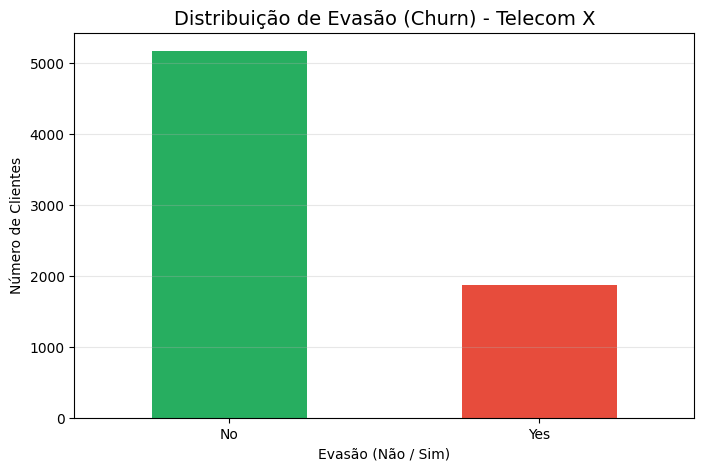

A taxa de evasão (Churn) atual da empresa é de: 26.54%


In [9]:
import matplotlib.pyplot as plt

# Contagem de quem saiu e quem ficou
distribuicao_churn = df_clean['Churn'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(8, 5))
distribuicao_churn.plot(kind='bar', color=['#27ae60', '#e74c3c'])

# Estilização do gráfico
plt.title('Distribuição de Evasão (Churn) - Telecom X', fontsize=14)
plt.ylabel('Número de Clientes')
plt.xlabel('Evasão (Não / Sim)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Calcular a porcentagem exata de perda
taxa_churn = (distribuicao_churn['Yes'] / len(df_clean)) * 100
print(f"A taxa de evasão (Churn) atual da empresa é de: {taxa_churn:.2f}%")

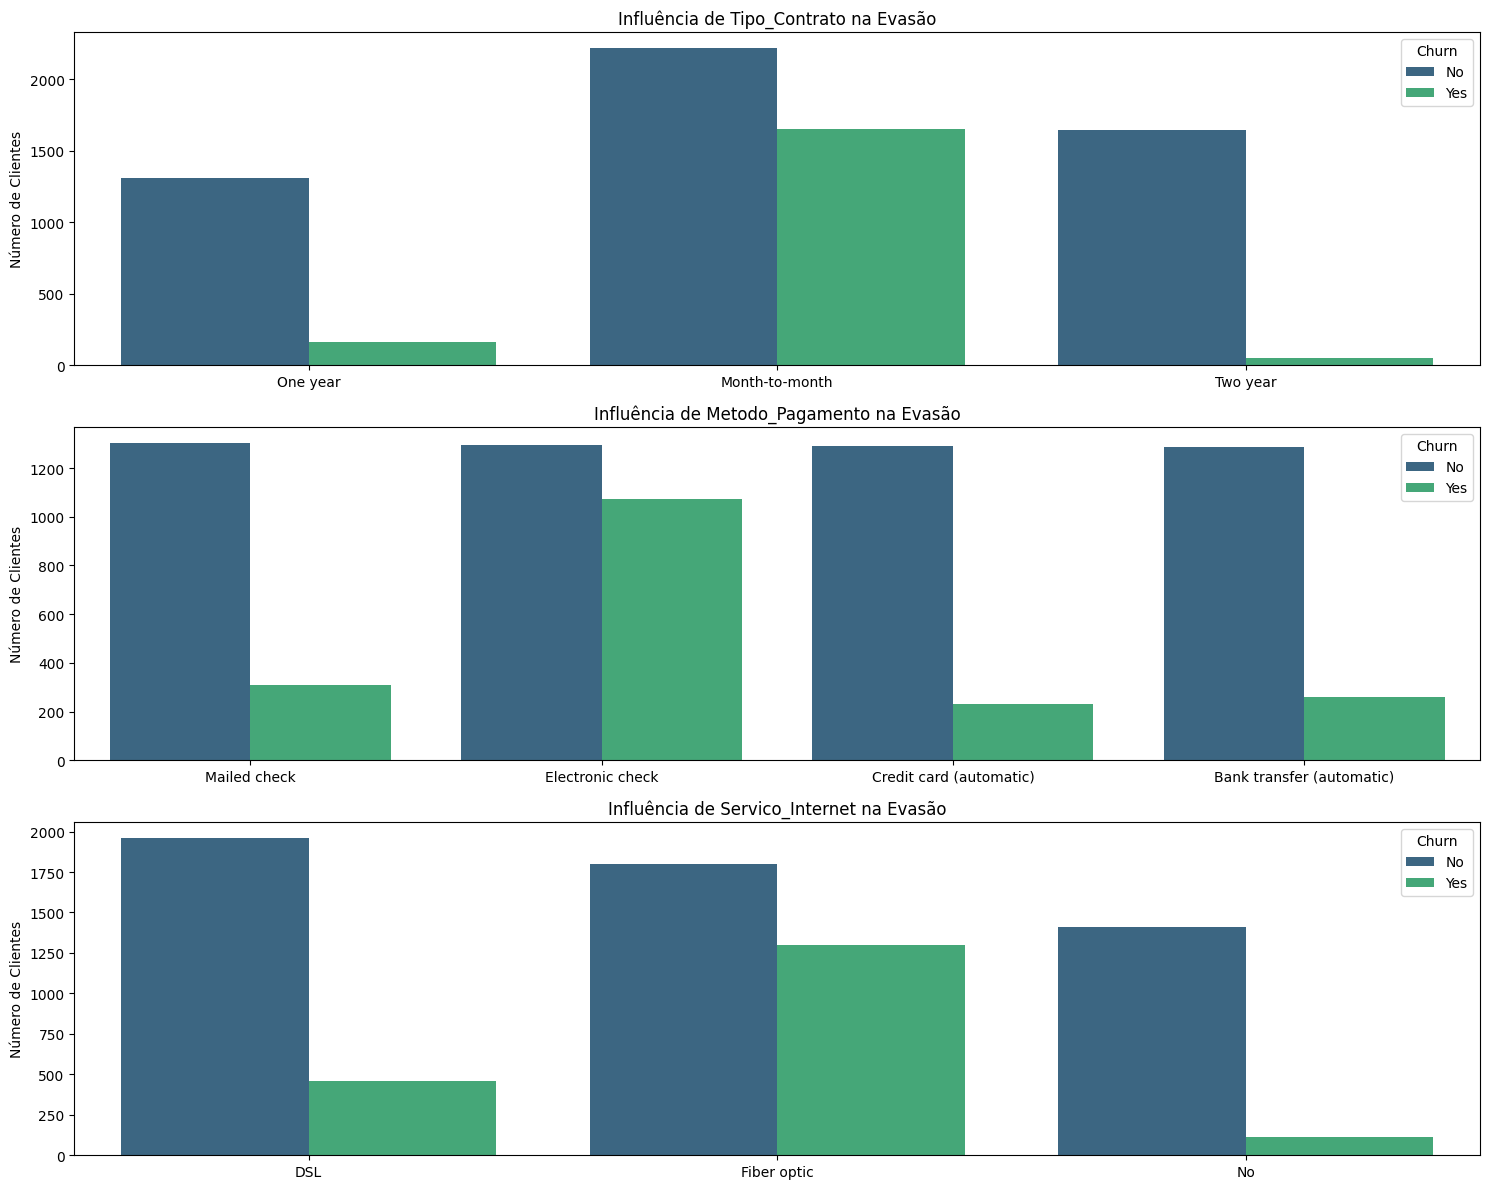

In [10]:
import seaborn as sns

# Selecionar colunas-chave para a comparação
colunas_categoricas = ['Tipo_Contrato', 'Metodo_Pagamento', 'Servico_Internet']

# Criar a figura para os gráficos
plt.figure(figsize=(15, 12))

for i, coluna in enumerate(colunas_categoricas):
    plt.subplot(3, 1, i+1)
    # Criar um gráfico de barras que mostra a contagem de Churn por categoria
    sns.countplot(x=coluna, hue='Churn', data=df_clean, palette='viridis')
    plt.title(f'Influência de {coluna} na Evasão', fontsize=12)
    plt.ylabel('Número de Clientes')
    plt.xlabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_383/235644149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=coluna, data=df_clean, palette='Set2')
/tmp/ipykernel_383/235644149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=coluna, data=df_clean, palette='Set2')
/tmp/ipykernel_383/235644149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=coluna, data=df_clean, palette='Set2')


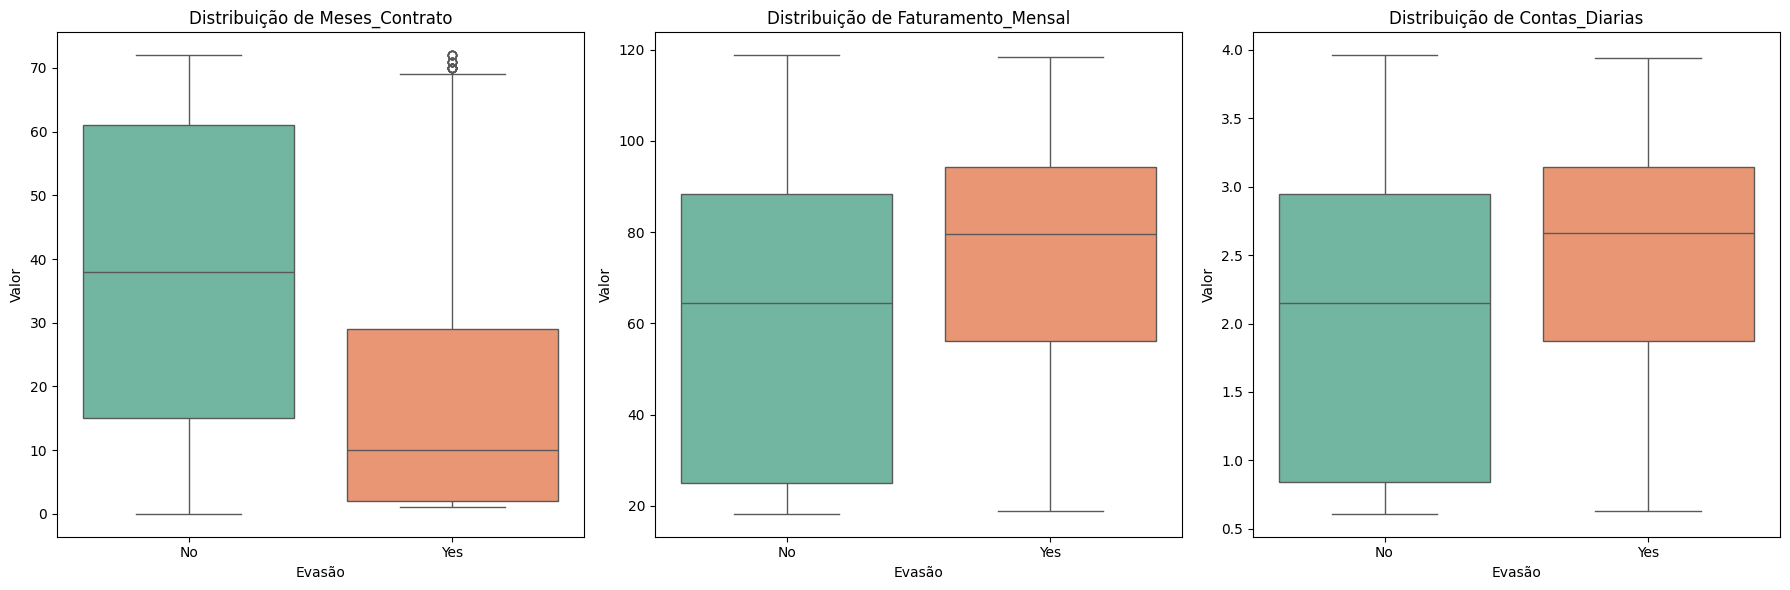

In [11]:
# Definir as variáveis numéricas para comparação
colunas_num = ['Meses_Contrato', 'Faturamento_Mensal', 'Contas_Diarias']

plt.figure(figsize=(18, 6))

for i, coluna in enumerate(colunas_num):
    plt.subplot(1, 3, i+1)
    # Criar um Boxplot comparando quem saiu (Yes) e quem ficou (No)
    sns.boxplot(x='Churn', y=coluna, data=df_clean, palette='Set2')
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel('Evasão')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

# Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X

## 1. Introdução
Este projeto teve como objetivo principal analisar o fenômeno de **Churn (evasão de clientes)** na Telecom X. A empresa enfrentava dificuldades em identificar os motivos que levavam ao cancelamento dos serviços. Através de técnicas de Ciência de Dados e Análise Exploratória (EDA), busquei identificar padrões comportamentais e financeiros que distinguem os clientes que permanecem dos que cancelam o contrato.

---

## 2. Limpeza e Tratamento de Dados (Processo de ETL)
Para garantir a integridade da análise, o processo seguiu rigorosas etapas de Extração, Transformação e Carga (ETL):

* **Extração:** Os dados foram importados diretamente de uma API em formato JSON.
* **Transformação (Normalização):** Como os dados estavam aninhados em dicionários, utilizei a técnica de `json_normalize` para expandir as categorias (*customer, phone, internet, account*) em colunas individuais.
* **Limpeza:** Identifiquei e removi registros onde a variável alvo (*Churn*) estava vazia.
    * Tratei a coluna `Faturamento_Total`, convertendo-a de texto para numérico e tratando 11 valores nulos (referentes a novos clientes).
    * A base final consolidada conta com **7.043 registros e 23 colunas**.
* **Feature Engineering:** Criei a métrica **"Contas_Diarias"**, dividindo o faturamento mensal por 30, para permitir uma visão granular do valor gerado por cada cliente:
$$Contas\_Diarias = \frac{Faturamento\_Mensal}{30}$$

---

## 3. Análise Exploratória de Dados (Insights Principais)
Após o tratamento, a análise revelou que a **Taxa de Churn atual da Telecom X é de 26,54%**. Isso significa que mais de um quarto da base de clientes abandonou a empresa no período analisado.

### Descobertas Estratégicas:
1.  **Perfil do Contrato:** Clientes com contratos do tipo **"Month-to-month" (Mês a mês)** representam a vasta maioria das evasões. Contratos anuais e bianuais mostram uma retenção drasticamente maior.
2.  **Tecnologia de Acesso:** Clientes de **Fibra Óptica** possuem uma taxa de cancelamento superior aos de DSL. Isso sugere uma possível insatisfação com o preço elevado ou com a estabilidade técnica deste serviço específico.
3.  **Método de Pagamento:** O uso de **"Electronic check"** está fortemente correlacionado com o Churn, indicando um ponto de atrito na jornada de pagamento desses clientes.
4.  **Tempo de Casa (Tenure):** O Churn é um problema de **curto prazo**. A mediana de tempo de contrato para quem sai é de apenas **10 meses**, enquanto clientes retidos costumam ultrapassar os 40 meses de fidelidade.

---

## 4. Conclusões
O "Cliente Típico em Risco" na Telecom X possui o seguinte perfil:
* Assina o serviço de Fibra Óptica;
* Opta pelo contrato mensal (sem fidelidade);
* Realiza pagamentos via cheque eletrônico;
* Possui um faturamento mensal acima da média ($R\$ 80,00$ vs $R\$ 65,00$ dos clientes fiéis).

---

## 5. Recomendação Estratégicas
Com base nos dados analisados, as recomendações são:

* **Migração de Contrato:** Criar incentivos financeiros (descontos ou bônus) para que clientes "mês a mês" migrem para contratos anuais, aumentando o custo de saída.
* **Fidelização de Novos Clientes:** Implementar uma régua de relacionamento intensiva nos primeiros 12 meses, período onde ocorre a maior parte das desistências.
* **Revisão do Produto Fibra:** Investigar a qualidade técnica e o custo-benefício do serviço de Fibra Óptica, visto que ele atrai clientes de alto valor, mas falha em retê-los.
* **Estímulo ao Débito Automático:** Oferecer benefícios para clientes que migrarem do cheque eletrônico para métodos de pagamento automáticos.